# Implementing the Backpropagation Algorithm

A Multilayer Perceptron (MLP) neural network is trained using the Backpropagation Algorithm on a challenging 8-class dataset. This report documents the full pipeline, covering data preprocessing and class balancing, architecture design and mathematical formulation, iterative hyperparameter tuning, and model evaluation.

## Initializing the Libraries

The following libraries are required:

| Library | Purpose |
|---------|--------|
| `numpy` | Numerical operations, matrix math, vectorized computations |
| `matplotlib` | Plotting learning curves and dataset distributions |
| `imblearn` | SMOTE for handling class imbalance (depends on `scipy`) |
| `os`, `csv` | File I/O for loading datasets and exporting results |
| `time` | Tracking training duration |

In [17]:
%pip install numpy matplotlib 
%pip install imblearn imbalanced-learn

#imbalanced learn (dependent on scipy) is neaded for SMOTE.

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\C5396183\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\C5396183\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [18]:
!python --version
!pip list | grep -E "imblearn"

Python 3.13.12


# The Dataset

## Loading the Dataset

The dataset is loaded from CSV files in the `dataset/` directory. Features are dense numerical vectors with 3486 dimensions, and labels range from 1 to 8 (8 classes). Labels are one-hot encoded into an `(N, 8)` matrix for the output layer — each row has a `1.0` at the index corresponding to its class.

A separate unlabeled test set is also loaded for final predictions.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import os, csv

# loading the data
DATASET     = np.loadtxt(os.path.join("dataset", "data.csv"), delimiter=",")
DATALABELS  = np.loadtxt(os.path.join("dataset", "data_labels.csv"), delimiter=",", dtype=int)
TESTSET     = np.loadtxt(os.path.join("dataset", "test_set.csv"), delimiter=",")

print(f"DATASET : {DATASET.shape}")
print(f"DATALABELS : {DATALABELS.shape}  classes: {np.unique(DATALABELS)}")
print(f"TESTSET : {TESTSET.shape}")

CLASSES = int(np.max(DATALABELS)) #1,2,3,4,5,6,7,8
LABELS = np.zeros((len(DATALABELS), CLASSES), dtype=float) #what class is the data
for _i, label in enumerate(DATALABELS):
    LABELS[_i, int(label) - 1] = 1.0

print(f"LABELS   : {LABELS.shape}")
print(f"Sample   : label {DATALABELS[0]} → {LABELS[0]}")


DATASET : (3486, 354)
DATALABELS : (3486,)  classes: [1 2 3 4 5 6 7 8]
TESTSET : (701, 354)
LABELS   : (3486, 8)
Sample   : label 8 → [0. 0. 0. 0. 0. 0. 0. 1.]


## Dataset Distribution

To observe how balanced or unbalanced the dataset is, a pie chart is generated showing the class distribution.

This is a critical step: imbalanced data can cause the network to become biased toward the majority class, predicting it disproportionately and ignoring minority classes entirely.

In [20]:

def piechart(datalabels, title='Class Distribution'): #use trainingset labels
    classcounts = np.bincount(datalabels, minlength=9)[1:]
    labels = [f"Class {i}" for i in range(1, len(classcounts) + 1)]

    plt.figure(figsize=(10, 8))
    plt.pie(classcounts, autopct=lambda pct: f'{int(pct/100.*sum(classcounts))}\n({pct:.1f}%)', startangle=90)
    plt.legend(labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title(title)
    plt.axis('equal')
    plt.show()

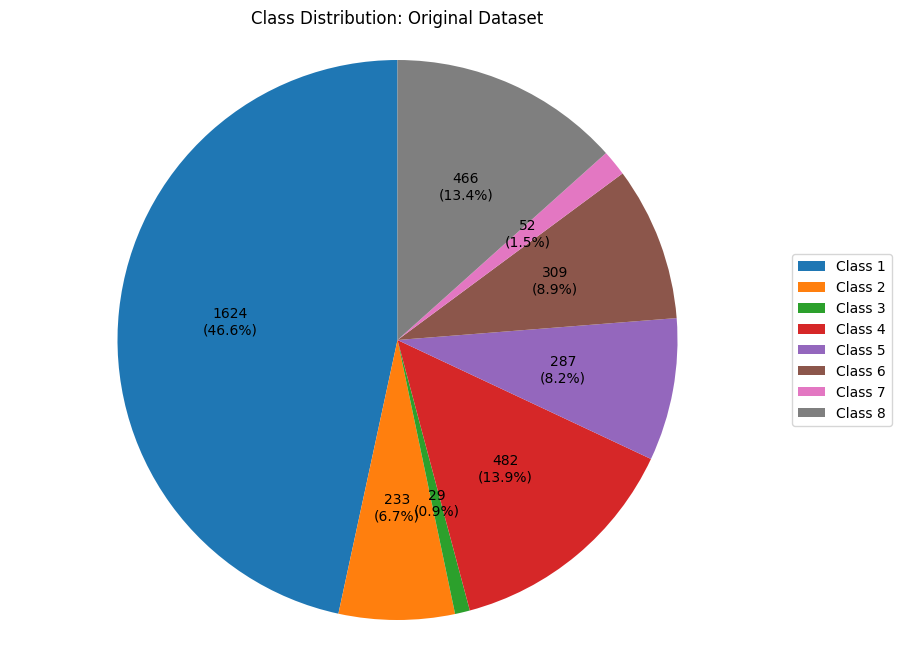

In [21]:
piechart(DATALABELS, "Class Distribution: Original Dataset") #the original

The distribution reveals a significant imbalance. **Class 1 dominates with 46.6%** of the dataset, while **Class 4 holds the smallest share**. This level of skew indicates that class balancing is necessary before training; without it, the network is likely to learn a trivial solution of always predicting the majority class.

## SMOTE (Synthetic Minority Over-sampling Technique)

To address the class imbalance, **SMOTE** is applied to the dataset. SMOTE generates synthetic samples for minority classes by interpolating between existing samples, effectively balancing the class distribution without simply duplicating data points.

In [22]:
X = DATASET
y = DATALABELS

from imblearn.over_sampling import SMOTE

X_balanced, y_balanced = SMOTE(random_state=50).fit_resample(X, y)

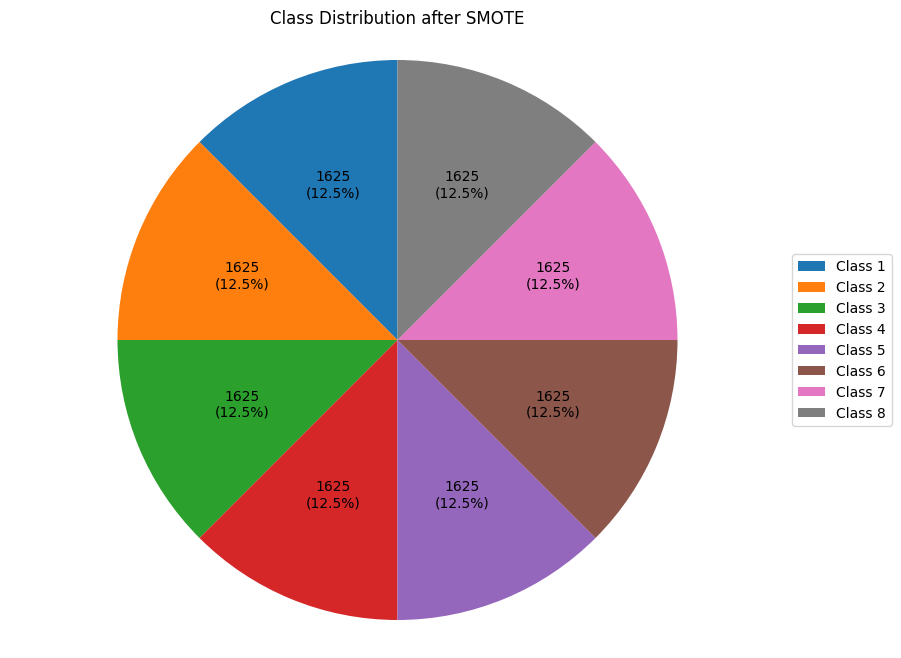

In [23]:
piechart(y_balanced, "Class Distribution after SMOTE")

The dataset is now balanced and ready for training: each class contains an equal number of samples, as confirmed by the pie chart.

> **Note on data leakage:** In this implementation, SMOTE was applied *before* splitting into training and validation sets. This means synthetic samples could influence the validation set, potentially leading to optimistic evaluation metrics. Ideally, SMOTE should only be applied to the training fold after the split. This trade-off was accepted for simplicity but is worth noting.

## Partitioning the Dataset

Now that the dataset is balanced and randomized, it is partitioned into training and validation sets using a custom `Partition` class.

- **Validation set:** 800 samples (randomly selected, `random_state=50`)
- **Training set:** remaining samples

The partitions are exported to CSV files (`training_set.csv`, `training_labels.csv`, `validation_set.csv`, `validation_labels.csv`) for reproducibility.

In [24]:
valsize = 800 # fixed validation set size

class Partition: #X is the dataset, y is the datalabels
    def __init__(self, X, y, valsize=800, outputdir="export", randomstate=50):
        os.makedirs(outputdir, exist_ok=True)
        rng = np.random.default_rng(randomstate)

        indices = rng.permutation(len(X))
        validx, trainidx = indices[:valsize], indices[valsize:]

        Xtrain, ytrain = X[trainidx], y[trainidx]
        Xval, yval = X[validx], y[validx]

        self.classes = np.unique(y)
        self.outputdir = outputdir
        self.validationset = Xval
        self.validationlabels = yval
        self.trainingset = Xtrain
        self.traininglabels = ytrain

        self.exportcsv(self.trainingset, "training_set.csv")
        self.exportcsv(self.traininglabels, "training_labels.csv")
        self.exportcsv(self.validationset, "validation_set.csv")
        self.exportcsv(self.validationlabels, "validation_labels.csv")

    def printdetails(self):
        print("Training Set Details")
        print(f"  Shape       : {self.trainingset.shape}")
        print(f"  Label shape : {self.traininglabels.shape}")
        print(f"  Feature min : {self.trainingset.min():.6f}")
        print(f"  Feature max : {self.trainingset.max():.6f}")
        print(f"  Feature mean: {self.trainingset.mean():.6f}")
        # print("\n  Class distribution:")
        # total = len(self.traininglabels)
        # for cls in self.classes:
        #     n = np.sum(self.traininglabels == cls)
        #     print(f"    Class {cls}: {n:>5}  ({n/total*100:.2f}%)")
        piechart(self.traininglabels, "Class Distribution of Training Set")
        print(f"\nValidation Set Details")
        print(f"  Shape       : {self.validationset.shape}")
        print(f"  Label shape : {self.validationlabels.shape}")
        piechart(self.validationlabels, "Class Distribution of Validation Set")

    #all export functions after split
    def exportcsv(self, data, filename):
        path = os.path.join(self.outputdir, filename)
        fmt = "%d" if data.ndim == 1 else "%g"
        np.savetxt(path, data, delimiter=",", fmt=fmt)
        print(f"Saved → {path}  shape: {data.shape}")

Saved → export\training_set.csv  shape: (12200, 354)
Saved → export\training_labels.csv  shape: (12200,)
Saved → export\validation_set.csv  shape: (800, 354)
Saved → export\validation_labels.csv  shape: (800,)
Training Set Details
  Shape       : (12200, 354)
  Label shape : (12200,)
  Feature min : 0.000000
  Feature max : 0.999990
  Feature mean: 0.040234


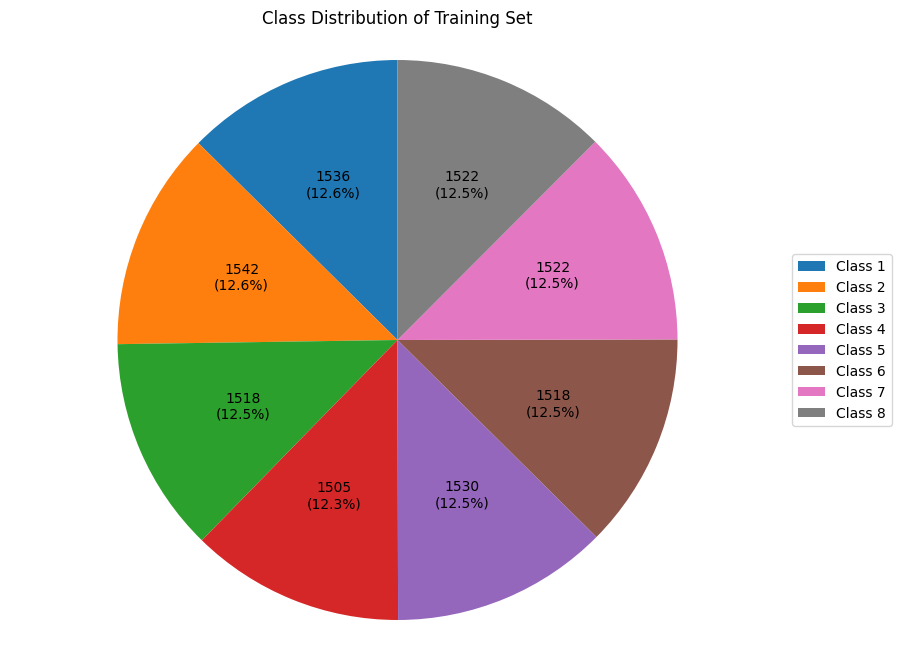


Validation Set Details
  Shape       : (800, 354)
  Label shape : (800,)


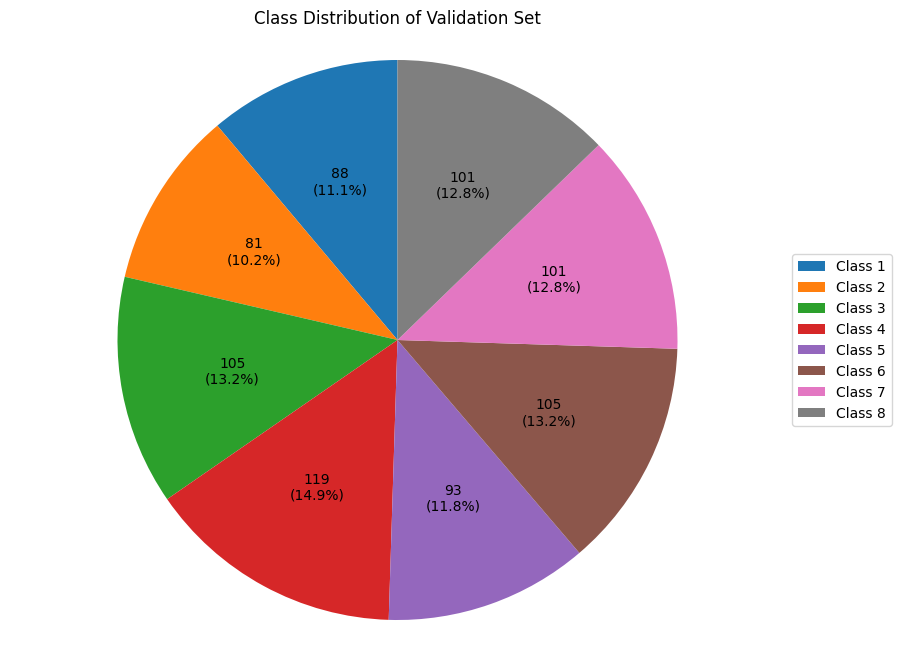

In [25]:
split = Partition(X_balanced, y_balanced)
split.printdetails()

## Batch Size

Mini-batch gradient descent is used with a **batch size of 8**. A generator function `minibatch()` yields sequential slices of the training set and labels for each batch iteration. This allows vectorized computation within each batch while still updating weights multiple times per epoch.

In [26]:
def minibatch(trainingset, traininglabels, batch_size=8):
    N = len(trainingset)
    indices = np.arange(N)
    for start in range(0, N, batch_size):
        i = indices[start : start + batch_size]
        yield trainingset[i], traininglabels[i]

In [27]:
batch_size = 8 #edit this to get the batch size you need
minibatch(split.trainingset, split.traininglabels, batch_size)

<generator object minibatch at 0x000001E3F49AB040>

# Setting up the Equations

The backpropagation algorithm is defined by a sequence of mathematical equations that govern forward propagation, error computation, delta calculation, and weight updating. The following sections lay out each equation as implemented in the code.

## Full Equation Reference: Backpropagation Algorithm

> **Notation**
> | Symbol | Meaning |
> |--------|---------|
> | $L$ | Total number of layers (output layer index) |
> | $l$ | Current layer index, $l \in \{1, \dots, L\}$ |
> | $i$ | Index of neuron in layer $l-1$; $i = 0$ is the bias input |
> | $j$ | Index of neuron in layer $l$ |
> | $k$ | Index of neuron in output layer $L$ |
> | $w^{(l)}_{j0}$ | Bias weight of neuron $j$ in layer $l$ (fixed input $\varphi_0 = +1$) |
> | $w^{(l)}_{ji}$ | Weight from neuron $i$ in layer $l-1$ to neuron $j$ in layer $l$ |
> | $v^{(l)}_j$ | Internal activity (pre-activation) of neuron $j$ in layer $l$ |
> | $\varphi_j$ | Activation function of neuron $j$; output $\varphi_j\!\left(v^{(l)}_j\right)$ |
> | $d_k$ | Desired (target) output for output neuron $k$ |
> | $e_k(n)$ | Error at output neuron $k$ at epoch $n$ |
> | $\mathcal{E}(n)$ | Mean square error over all output neurons at epoch $n$ |
> | $\eta$ | Learning rate |
> | $\alpha$ | Momentum coefficient |
> | $a, b$ | Depends on activation function. Used by Logistic and Tanh as constant/s, Leaky ReLU negative-side slope, $\gamma \in (0,1)$ |
> | $n$ | Discrete time step (epoch) |
 
---

## 1. Forward Propagation to get internal activity $v(n)$ and outputs $y_{out}$

### 1.1 Internal Activity
 
The sum begins at $i = 0$ to include the bias weight $w^{(l)}_{j0}$ directly. The bias neuron has a fixed output of $+1$, so $w^{(l)}_{j0} \cdot 1 = w^{(l)}_{j0}$:
 
$$v^{(l)}_j(n) = \sum_{i=0}^{p} w^{(l)}_{ji}(n)\, \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
where $p$ is the number of neurons in layer $l-1$ (excluding the bias), and the bias input is $\varphi_0 = +1$ (constant).
 
### 1.2 Neuron Output
 
$$y_j(n) = \varphi_j\!\left(v^{(l)}_j(n)\right)$$
 
where $\varphi_j$ is the chosen activation function (see Section 2).

## 2. Choosing the Activation Functions
 
Derivatives are expressed in terms of the neuron output $o(n) = \varphi(v(n))$ directly, using constants $a$ and $b$ where applicable.
 
### 2.1 Logistic (Sigmoid)
 
$$\varphi(v) = \frac{1}{1 + e^{-av}}, \quad a > 0$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = a \cdot o(n)\,\bigl(1 - o(n)\bigr)$$

> Given: $a = 2.0$
 
---
 
### 2.2 Hyperbolic Tangent (Tanh)
 
$$\varphi(v) = a \tanh(bv) = a \cdot \frac{e^{bv} - e^{-bv}}{e^{bv} + e^{-bv}}$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = \frac{b}{a}\left(a - o(n)\right)\!\left(a + o(n)\right)$$
 
> Given: $a = 1.716,\; b = 0.66667$
 
---
 
### 2.3 Leaky ReLU
 
$$\varphi(v) = \begin{cases} v & \text{if } v > 0 \\ \gamma\, v & \text{if } v \leq 0 \end{cases}, \quad \gamma \in (0,1)$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = \begin{cases} 1 & \text{if } o(n) > 0 \\ \gamma & \text{if } o(n) \leq 0 \end{cases}$$
 
---

In [28]:
# ACTIVATION FUNCTIONS
def logistic(v, a=1.0):
    phi = 1.0 / (1.0 + np.exp(-a * v))
    return phi

def tanh(v, a=1.0, b=1.0):
    phi = a * np.tanh(b * v)
    return phi
 
def leakyrelu(v, gamma=0.01):
    phi = np.where(v > 0, v, gamma * v)
    return phi
 
def errorSignal(dk, phiVk):
    return dk - phiVk
 
def meanSquareError(ek):
    return 0.5 * np.dot(ek, ek)

# DERIVATIVES
RELU_CLIP = 5.0 #for relu to converge

def dlogistic(o, a=1.0):
    dphi = a * o * (1.0 - o)
    return dphi
 
def dtanh(o, a=1.0, b=1.0):
    dphi = (b / a) * (a - o) * (a + o)
    return dphi
 
def dleakyrelu(o, gamma=0.01):
    dphi = np.where(o > 0, 1.0, gamma)
    return dphi
 
# DERIVATIVE CALL
def callDerivative(method, o, config):
    if method == 0:
        return dlogistic(o, config['a_l']), None
    elif method == 1:
        return dtanh(o, config['a_tanh'], config['b_tanh']), None
    else:
        return dleakyrelu(o, config['a_relu']), RELU_CLIP
 
# ACTIVATION CALL
def callActivation(method, v, config):
    if method == 0:
        return logistic(v, config['a_l'])
    elif method == 1:
        return tanh(v, config['a_tanh'], config['b_tanh'])
    else:
        return leakyrelu(v, config['a_relu'])

## 3. Error & Mean Square Error
 
### 3.1 Error Signal at Output Neuron $k$
 
$$o_k(n)= s \varphi_k\!\left(v^{(L)}_k(n)\right)$$
 
### 3.2 Mean Square Error
 
$$\mathcal{E}(n) = \frac{1}{2} \sum_{k \in \mathcal{C}} e_k^2(n)$$
 
where $\mathcal{C}$ is the set of output neurons.
 
---

## 4. Backpropagation Delta Equations
 
### 4.1 Output Layer Delta
 
$$\delta^{(L)}_k(n) = e_k(n) \cdot \varphi'\!\left(v^{(L)}_k(n)\right)$$
 
### 4.2 Hidden Layer Delta
 
For layer $l \in \{L-1,\, L-2,\, \dots,\, 1\}$:
 
$$\delta^{(l)}_j(n) = \varphi'\!\left(v^{(l)}_j(n)\right) \cdot \sum_{k}\, \delta^{(l+1)}_k(n)\, w^{(l+1)}_{kj}(n)$$
 
The hidden-layer delta propagates the error signal backward by weighting each upstream delta $\delta^{(l+1)}_k$ by the corresponding weight $w^{(l+1)}_{kj}$ and scaling by the local derivative $\varphi'(v^{(l)}_j)$.
 
---

## 5. Weight Update: Negative Gradient with Momentum
 
All weights $w^{(l)}_{ji}$ include the bias weights at $i = 0$ (with fixed input $\varphi_0 = +1$). No separate bias update is needed.
 
The weight correction follows the **negative gradient** of $\mathcal{E}(n)$ with respect to $w^{(l)}_{ji}$:
 
$$-\frac{\partial \mathcal{E}(n)}{\partial w^{(l)}_{ji}(n)} = \delta^{(l)}_j(n) \cdot \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
### 5.1 Weight Increment (Generalized Delta Rule + Momentum)
 
$$\Delta w^{(l)}_{ji}(n) = \underbrace{\alpha\, \Delta w^{(l)}_{ji}(n-1)}_{\text{momentum}} \;-\; \underbrace{\eta\, \frac{\partial \mathcal{E}(n)}{\partial w^{(l)}_{ji}(n)}}_{\text{negative gradient}}$$
 
Substituting the gradient expression:
 
$$\Delta w^{(l)}_{ji}(n) = \alpha\, \Delta w^{(l)}_{ji}(n-1) \;+\; \eta\, \delta^{(l)}_j(n)\, \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
### 5.2 Weight Update Rule
 
$$w^{(l)}_{ji}(n+1) = w^{(l)}_{ji}(n) + \Delta w^{(l)}_{ji}(n)$$
 
> **Bias weights** ($i = 0$) are updated identically using $\varphi_0 = +1$, so:
> $$\Delta w^{(l)}_{j0}(n) = \alpha\, \Delta w^{(l)}_{j0}(n-1) \;+\; \eta\, \delta^{(l)}_j(n)$$
 
> **Momentum note:** When $\alpha = 0$, this reduces to the standard (vanilla) delta rule. When $\alpha > 0$, the update accumulates a fraction of the previous step, smoothing oscillations and accelerating convergence along consistent gradient directions.
 
---

In [29]:
class OutputLayer:
    def __init__(self, method, w_old, config, dw_prev=None):
        self.config = config
        self.method = method
        self.v = []
        self.o = []
        self.d = []
        self.w_old = w_old
        self.size = config['size']
        self.delta = []
        self.error = []
        self.mse = 0.0
        self.w_new = []
        self.totaltime = 0
 
        self.dw_prev = dw_prev if dw_prev is not None else np.zeros_like(w_old)
        self.phiIn = None
        self.gradient = np.zeros_like(w_old)
 
    def forward(self, phiIn):
        self.phiIn = phiIn
        self.v = self.w_old @ phiIn
        self.o = callActivation(self.method, self.v, self.config)
 
    def computeError(self, d):
        self.d = np.asarray(d, dtype=float)
        self.error = errorSignal(self.d, self.o)
        self.mse = meanSquareError(self.error)
 
    def computeDelta(self):
        dphi, _ = callDerivative(self.method, self.o, self.config)
        self.delta = self.error * dphi
 
    def accumulateGradient(self):
        self.gradient += np.outer(self.delta, self.phiIn)
 
    def resetGradient(self):
        self.gradient = np.zeros_like(self.w_old)
 
    def updateWeights(self, batch_size=1):
        dw = self.config['alpha'] * self.dw_prev + self.config['eta'] * (self.gradient / batch_size)
        self.w_new = self.w_old + dw
        self.dw_prev = dw
        self.gradient = np.zeros_like(self.w_old)
 
 
class HiddenLayer:
    def __init__(self, method, w_old, config, size=8, dw_prev=None):
        self.config = config
        self.method = method
        self.v = []
        self.y = []
        self.w_old = w_old
        self.size = size
        self.delta = 0.0
        self.w_new = []

        self.dw_prev = dw_prev if dw_prev is not None else np.zeros_like(w_old)
        self.phiIn = None
        self.gradient = np.zeros_like(w_old)
 
    def forward(self, phiIn):
        self.phiIn = phiIn
        self.v = self.w_old @ phiIn
        self.y = callActivation(self.method, self.v, self.config)
        return np.concatenate(([1.0], self.y))
 
    def computeDelta(self, nextLayer):
        dphi, _ = callDerivative(self.method, self.y, self.config)
        w_nobias = nextLayer.w_old[:, 1:]
        propagated = w_nobias.T @ nextLayer.delta
        self.delta = dphi * propagated
 
    def accumulateGradient(self):
        self.gradient += np.outer(self.delta, self.phiIn)
 
    def resetGradient(self):
        self.gradient = np.zeros_like(self.w_old)
 
    def updateWeights(self, batch_size=1):
        dw = self.config['alpha'] * self.dw_prev + self.config['eta'] * (self.gradient / batch_size)
        _, clip = callDerivative(self.method, self.y, self.config)
        if clip is not None:
            norm = np.linalg.norm(dw)
            if norm > clip:
                dw = dw * (clip / norm)
        self.w_new = self.w_old + dw
        self.dw_prev = dw
        self.gradient = np.zeros_like(self.w_old)
        return self.w_new
 
 
class Epoch:
    def __init__(self, split, config):
        self.config = config
        self.label = ""
        inputsize  = split.trainingset.shape[1] + 1
        hiddensize = config['size']
        outputsize = len(split.classes)
        #randomizing start weights
        
        np.random.seed(50) #for reproducibility
        Wi = np.random.randn(hiddensize, inputsize) * 0.01
        Wj = np.random.randn(hiddensize, hiddensize + 1)  * 0.01
        Wk = np.random.randn(outputsize, hiddensize + 1)  * 0.01

        self.hiddenlayer_i = HiddenLayer(config['methods'][0], Wi, config, size=hiddensize)
        self.hiddenlayer_j = HiddenLayer(config['methods'][1], Wj, config, size=hiddensize)
        self.outputlayer_k = OutputLayer(config['methods'][2], Wk, config)

        self.test_set = list(zip(split.validationset, split.validationlabels))
        self.error = 0.0 #for scores
        
        self.batch_iteration = 0
        self.epoch_iteration = 0

        #for export
        self.train_errors = []
        self.val_errors = []
        self.epochs_logged = []
        
        self.tp = self.tn = self.fp = self.fn = 0.0
        self.p = self.r = self.a = self.f1 = self.matthews = 0.0

        self.trainingset = split.trainingset
        self.traininglabels = split.traininglabels
 
    def run(self, x, d):
        x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
 
        # Forward Prop
        phi_i = self.hiddenlayer_i.forward(x_biased)
        phi_j = self.hiddenlayer_j.forward(phi_i)
        self.outputlayer_k.forward(phi_j)
 
        outputsize = self.outputlayer_k.w_old.shape[0]
        d_onehot = np.zeros(outputsize)
        d_onehot[int(d) - 1] = 1.0

        # Error calcs
        self.outputlayer_k.computeError(d_onehot)
        self.error = self.outputlayer_k.mse
 
        # Backprop
        self.outputlayer_k.computeDelta()
        self.hiddenlayer_j.computeDelta(self.outputlayer_k)
        self.hiddenlayer_i.computeDelta(self.hiddenlayer_j)
 
        # Accumulate (batch_size=1, so gradient = outer(delta, phiIn))
        self.outputlayer_k.accumulateGradient()
        self.hiddenlayer_j.accumulateGradient()
        self.hiddenlayer_i.accumulateGradient()
 
        # Weight updates
        self.outputlayer_k.updateWeights()
        self.hiddenlayer_j.updateWeights()
        self.hiddenlayer_i.updateWeights()
 
        # Advance w_old → w_new
        self.outputlayer_k.w_old = self.outputlayer_k.w_new
        self.hiddenlayer_j.w_old = self.hiddenlayer_j.w_new
        self.hiddenlayer_i.w_old = self.hiddenlayer_i.w_new
 
        self.epoch_iteration += 1
 
    def run_batch(self, X_batch, D_batch):
        batch_size = len(X_batch)
        error = 0.0
 
        for SAMPLE in range(batch_size):
            x_biased = np.concatenate(([1.0], np.asarray(X_batch[SAMPLE], dtype=float)))
 
            # Forward Prop
            phi_i = self.hiddenlayer_i.forward(x_biased)
            phi_j = self.hiddenlayer_j.forward(phi_i)
            self.outputlayer_k.forward(phi_j)
 
            outputsize = self.outputlayer_k.w_old.shape[0]
            d_onehot = np.zeros(outputsize)
            d_onehot[int(D_batch[SAMPLE]) - 1] = 1.0

            # Error calcs
            self.outputlayer_k.computeError(d_onehot)
            error += self.outputlayer_k.mse
 
            # Backprop
            self.outputlayer_k.computeDelta()
            self.hiddenlayer_j.computeDelta(self.outputlayer_k)
            self.hiddenlayer_i.computeDelta(self.hiddenlayer_j)
 
            # Accumulate
            self.outputlayer_k.accumulateGradient()
            self.hiddenlayer_j.accumulateGradient()
            self.hiddenlayer_i.accumulateGradient()
 
        # Weight updates uses batch_size from config
        self.outputlayer_k.updateWeights(batch_size)
        self.hiddenlayer_j.updateWeights(batch_size)
        self.hiddenlayer_i.updateWeights(batch_size)
 
        # Advance w_old to w_new
        self.outputlayer_k.w_old = self.outputlayer_k.w_new
        self.hiddenlayer_j.w_old = self.hiddenlayer_j.w_new
        self.hiddenlayer_i.w_old = self.hiddenlayer_i.w_new
 
        self.error = error / batch_size
        self.batch_iteration += 1
        return self.error
 
    def Scores(self):
        n_classes = self.outputlayer_k.w_old.shape[0]
        confmat = np.zeros((n_classes, n_classes), dtype=int)
        for x, d in self.test_set:
            x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
            phi_i = self.hiddenlayer_i.forward(x_biased)
            phi_j = self.hiddenlayer_j.forward(phi_i)
            self.outputlayer_k.forward(phi_j)
 
            predicted = np.argmax(self.outputlayer_k.o)
            actual = int(d) - 1   # labels are 1-8; convert to 0-indexed
 
            confmat[actual, predicted] += 1
 
        self.confmat = confmat
        total   = confmat.sum()
        correct = np.trace(confmat)
        self.a  = correct / total if total > 0 else 0.0
 
        # --- Per-class TP, TN, FP, FN and Macro-averaged precision, recall, F1, totaltime ---
        tps, tns, fps, fns = [], [], [], []
        precisions, recalls, f1s = [], [], []
        for c in range(n_classes):
            tp = confmat[c, c]
            fp = confmat[:, c].sum() - tp
            fn = confmat[c, :].sum() - tp
            tn = total - tp - fp - fn
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1   = 2*prec*rec / (prec + rec) if (prec + rec) > 0 else 0.0
            tps.append(int(tp))
            tns.append(int(tn))
            fps.append(int(fp))
            fns.append(int(fn))
            precisions.append(prec)
            recalls.append(rec)
            f1s.append(f1)
        self.tps = tps
        self.tns = tns
        self.fps = fps
        self.fns = fns
        self.precisions = precisions
        self.recalls = recalls
        self.f1s = f1s
        self.p  = np.mean(precisions)
        self.r  = np.mean(recalls)
        self.f1 = np.mean(f1s)

        # Matthews Correlation Coefficient (multiclass)
        tk = confmat.sum(axis=0)
        pk = confmat.sum(axis=1)
        c_total = confmat.sum()
        c_correct = np.trace(confmat)
        cov_yy = c_total * c_correct - np.dot(tk, pk)
        cov_xx = c_total**2 - np.dot(tk, tk)
        cov_yy_denom = c_total**2 - np.dot(pk, pk)
        denom = np.sqrt(float(cov_xx) * float(cov_yy_denom))
        self.matthews = float(cov_yy) / denom if denom > 0 else 0.0
 
    def printConfusionMatrix(self):
        n = self.confmat.shape[0]
        print("Confusion Matrix (rows=Actual, cols=Predicted):")
        header = "      " + "  ".join(f"P{i+1:>2}" for i in range(n))
        print(header)
        for i in range(n):
            row = "  ".join(f"{self.confmat[i, j]:>4}" for j in range(n))
            print(f"A{i+1:>2} | {row}")
 
    def printScores(self):
        self.printConfusionMatrix()
        n = self.confmat.shape[0]
        print()
        print("Per-Class Metrics:")
        print(f"  {'Class':<8} {'TP':>6} {'TN':>6} {'FP':>6} {'FN':>6} {'Precision':>10} {'Recall':>10} {'F1 Score':>10}")
        print(f"  {'-'*8} {'-'*6} {'-'*6} {'-'*6} {'-'*6} {'-'*10} {'-'*10} {'-'*10}")
        for c in range(n):
            print(f"  {'Class '+str(c+1):<8} {self.tps[c]:>6} {self.tns[c]:>6} {self.fps[c]:>6} {self.fns[c]:>6} {self.precisions[c]:>10.5f} {self.recalls[c]:>10.5f} {self.f1s[c]:>10.5f}")
        print()
        print("Summary Metrics:")
        print(f"  Error (MSE):                  {self.error:.5f}")
        print(f"  Accuracy:                     {self.a:.5f}")
        print(f"  Precision (Macro-Avg):        {self.p:.5f}")
        print(f"  Recall (Macro-Avg):           {self.r:.5f}")
        print(f"  F1 Score (Macro-Avg):         {self.f1:.5f}")
        print(f"  Matthews Correlation Coeff:   {self.matthews:.5f}")
 
    def log_epoch(self, epoch_idx, train_error, val_error):
        self.epochs_logged.append(epoch_idx)
        self.train_errors.append(train_error)
        self.val_errors.append(val_error)

    def exportErrors(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        filepath = os.path.join(outputdir, "errors.csv")

        with open(filepath, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['epoch', 'train_error', 'val_error'])

            for ep, tr, val in zip(self.epochs_logged, self.train_errors, self.val_errors):
                writer.writerow([ep, tr, val])
 
    def exportScores(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        filepath = os.path.join(outputdir, "scores.csv")
        n = self.confmat.shape[0]
        with open(filepath, 'w', newline='') as f:
            writer = csv.writer(f)

            # Write header
            header = ['Epoch']
            for c in range(n):
                cn = f"class{c+1}"
                header.extend([f"{cn}_TP", f"{cn}_TN", f"{cn}_FP", f"{cn}_FN",
                            f"{cn}_Precision", f"{cn}_Recall", f"{cn}_F1"])
            header.extend(['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'matthews', "Time"])
            writer.writerow(header)

            # Write the row
            row = [self.epoch_iteration]
            for c in range(n):
                row.extend([self.tps[c], self.tns[c], self.fps[c], self.fns[c],
                            self.precisions[c], self.recalls[c], self.f1s[c]])
            row.extend([self.a, self.p, self.r, self.f1, self.matthews, self.totaltime])
            writer.writerow(row)

    def exportConfusionMatrix(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        filepath = os.path.join(outputdir, "confusion_matrix.csv")
        n = len(self.tps)  # number of classes

        with open(filepath, 'w', newline='') as f:
            writer = csv.writer(f)
            # Header
            writer.writerow(['Class', 'TP', 'TN', 'FP', 'FN', 'Precision', 'Recall', 'F1'])
            # Write per-class stats
            for c in range(n):
                writer.writerow([
                    f'Class {c+1}',
                    self.tps[c],
                    self.tns[c],
                    self.fps[c],
                    self.fns[c],
                    f'{self.precisions[c]:.5f}',
                    f'{self.recalls[c]:.5f}',
                    f'{self.f1s[c]:.5f}'
                ])
        print(f"Saved → {filepath}  shape: {n} classes")

    def exportWeights(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        weights = [
            (self.hiddenlayer_i.w_old, "Wi"),
            (self.hiddenlayer_j.w_old, "Wj"),
            (self.outputlayer_k.w_old, "Wk"),
        ]
        path = os.path.join(outputdir, "trained_weights.csv")
        with open(path, "w", newline="") as f:
            writer = csv.writer(f)
            for data, label in weights:
                writer.writerow([label])
                if data.ndim == 1:
                    writer.writerow(data.astype(int))
                else:
                    for row in data:
                        writer.writerow(row)
                writer.writerow([])
        print(f"Saved → {path}")

    def exportAll(self, outputdir="export"):
        self.exportErrors(outputdir)
        self.exportScores(outputdir)
        self.exportConfusionMatrix(outputdir)
        self.exportWeights(outputdir)


# Training Phase

With the equations implemented in the `HiddenLayer`, `OutputLayer`, and `Epoch` classes, the training phase can begin. Each training run processes the dataset in mini-batches, computes training and validation errors per epoch, and prints progress every 5 epochs.

## Hyperparameters Setup

Two network configurations are defined below, differing primarily in their activation functions:

| Parameter | Network A (Tanh) | Network B (Leaky ReLU) |
|-----------|-------------------|------------------------|
| Hidden activation | Tanh ($a=1.716, b=2/3$) | Leaky ReLU ($\gamma=0.01$) |
| Output activation | Logistic ($a=1.0$) | Logistic ($a=1.0$) |
| Learning rate ($\eta$) | 0.85 | 0.85 |
| Momentum ($\alpha$) | 0.9 | 0.9 |
| Hidden layer size | 8 | 8 |
| Batch size | 8 | 8 |

The architecture uses **two hidden layers** (layers $i$ and $j$) plus an **output layer** ($k$), with 8 output neurons for 8 classes.

In [30]:
#hyperparameters updated
NetworkA = {
        'methods'    : [1, 1, 0],  # [i, j, k] — 0 logistic, 1 tanh, 2 relu
        'a_l'        : 1.0,        # logistic slope
        'a_tanh'     : 1.716,      # tanh a
        'b_tanh'     : 0.66666,    # tanh b
        'a_relu'     : 0.01,       # leaky relu gamma
        'eta'        : 0.85,       # learning rate
        'alpha'      : 0.9,        # momentum constant
        'size'       : 8,          # hidden layer size
        'batch_size' : 8,          # mini-batch size
    }
NetworkB = {
        'methods'    : [2, 2, 0],  # [i, j, k] — 0 logistic, 1 tanh, 2 relu
        'a_l'        : 1.0,        # logistic slope
        'a_tanh'     : 1.716,      # tanh a
        'b_tanh'     : 0.66666,    # tanh b
        'a_relu'     : 0.01,       # leaky relu gamma
        'eta'        : 0.85,        # learning rate
        'alpha'      : 0.9,        # momentum constant
        'size'       : 8,          # hidden layer size
        'batch_size' : 8,          # mini-batch size
    }
#the main engine:
epochA = Epoch(split, NetworkA)  # layers built inside
# epochA.label = "Network A - Tanh (eta=0.85)"

epochB = Epoch(split, NetworkB)
# epochB.label = "Network B - Leaky ReLU (eta=0.85)"

## Training: Network A

Training commences with Network A using the default hyperparameters. Training error and runtime are reported every 5 epochs.

With the default configuration (`eta=0.85`, `alpha=0.9`, `size=8`), the training error remained essentially flat across all 100 epochs. The resulting macro-averaged F1 score was **0.2261**, indicating the network collapsed to predicting a single output class exclusively. This behaviour confirms that the learning rate is too aggressive and the momentum too high, causing weight updates to overshoot the optimal region of the loss surface.

In [31]:
import time

def computeValError(epoch):
    total_mse = 0.0
    n = len(epoch.test_set)
    for x, d in epoch.test_set:
        x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
        phi_i = epoch.hiddenlayer_i.forward(x_biased)
        phi_j = epoch.hiddenlayer_j.forward(phi_i)
        epoch.outputlayer_k.forward(phi_j)
        n_out = epoch.outputlayer_k.w_old.shape[0]
        d_onehot = np.zeros(n_out)
        d_onehot[int(d) - 1] = 1.0
        epoch.outputlayer_k.computeError(d_onehot)
        total_mse += epoch.outputlayer_k.mse
    return total_mse / n if n > 0 else 0.0


def learningcurve(epochs, networkname="Learning Curve: Training vs Validation Error"):
    plt.figure(figsize=(10, 5))

    for i, epoch in enumerate(epochs, 1):
        train_errors = epoch.train_errors
        val_errors   = epoch.val_errors
        label = epoch.label
        # label = epoch.label if epoch.label else f"Model {i}"

        ep_range = range(1, len(train_errors) + 1)

        plt.plot(ep_range, train_errors, label=f"{label} - Train")
        plt.plot(ep_range, val_errors,   label=f"{label} - Val")

    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(networkname)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def train(epoch, networkname = "Learning Curve: Training vs Validation Error", epochs=100):
    batch_size   = epoch.config.get('batch_size', 8)

    totaltime = 0
    for ep in range(epochs):
        start = time.time()
        epoch_error = 0.0
        n_batches = 0
        for xbatch, dbatch in minibatch(epoch.trainingset, epoch.traininglabels, batch_size):
            epoch_error += epoch.run_batch(xbatch, dbatch)
            n_batches += 1
        epoch_error /= max(n_batches, 1)
        
        epoch.error = epoch_error #updating errors
        epoch.epoch_iteration = ep + 1
        val_error = computeValError(epoch)

        epoch.log_epoch(epoch.epoch_iteration, epoch_error, val_error)

        elapsed = time.time() - start
        totaltime += elapsed
        if (ep + 1) % 5 == 0:
            print(f"Epoch {ep+1:>4}  Train: {epoch_error:.5f}  Val: {val_error:.5f}  Time: {elapsed:.3f}s")
    epoch.totaltime = totaltime
    epoch.Scores()
    epoch.printScores()
    print(f"Total training time: {totaltime:.2f}s")
    learningcurve([epoch], networkname)

Epoch    5  Train: 0.50000  Val: 0.50000  Time: 0.534s
Epoch   10  Train: 0.49991  Val: 0.49987  Time: 0.563s
Epoch   15  Train: 0.50000  Val: 0.50000  Time: 0.534s
Epoch   20  Train: 0.50000  Val: 0.50000  Time: 0.580s
Epoch   25  Train: 0.49999  Val: 0.49993  Time: 0.541s
Epoch   30  Train: 0.50000  Val: 0.49999  Time: 0.528s
Epoch   35  Train: 0.49999  Val: 0.49995  Time: 0.601s
Epoch   40  Train: 0.49967  Val: 0.49998  Time: 0.600s
Epoch   45  Train: 0.49975  Val: 0.50000  Time: 0.629s
Epoch   50  Train: 0.50000  Val: 0.50000  Time: 0.550s
Epoch   55  Train: 0.50000  Val: 0.50000  Time: 0.603s
Epoch   60  Train: 0.50000  Val: 0.50000  Time: 0.700s
Epoch   65  Train: 0.50000  Val: 0.50000  Time: 0.565s
Epoch   70  Train: 0.50000  Val: 0.50000  Time: 0.827s
Epoch   75  Train: 0.50000  Val: 0.50000  Time: 0.631s
Epoch   80  Train: 0.50000  Val: 0.50000  Time: 0.568s
Epoch   85  Train: 0.50000  Val: 0.50000  Time: 0.618s
Epoch   90  Train: 0.50000  Val: 0.50000  Time: 0.579s
Epoch   95

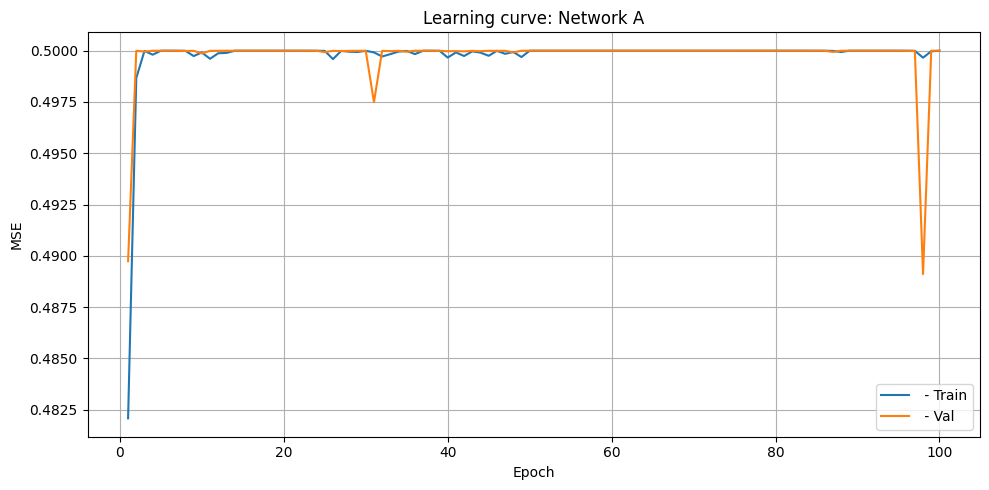

Saved → export/networkA/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA/trained_weights.csv


In [32]:
train(epochA, "Learning curve: Network A") #network A

epochA.exportAll("export/networkA/")

### Improvements for Network A

Given that the error does not converge with the default parameters, the following adjustments are applied: the learning rate is reduced from 0.85 to **0.1**, momentum is reduced from 0.9 to **0.5**, and the hidden layer size is increased from 8 to **12**.

These modifications address the core issue of the default configuration: overly large weight updates that prevent convergence to a stable minimum of the loss surface.

Epoch    5  Train: 0.43739  Val: 0.43657  Time: 0.767s
Epoch   10  Train: 0.19413  Val: 0.16652  Time: 0.684s
Epoch   15  Train: 0.08984  Val: 0.07617  Time: 0.629s
Epoch   20  Train: 0.05611  Val: 0.07487  Time: 0.603s
Epoch   25  Train: 0.04242  Val: 0.04777  Time: 0.689s
Epoch   30  Train: 0.03520  Val: 0.05384  Time: 0.599s
Epoch   35  Train: 0.02923  Val: 0.09013  Time: 0.746s
Epoch   40  Train: 0.02599  Val: 0.04906  Time: 0.718s
Epoch   45  Train: 0.02367  Val: 0.05419  Time: 0.616s
Epoch   50  Train: 0.02270  Val: 0.04861  Time: 0.597s
Epoch   55  Train: 0.02098  Val: 0.03014  Time: 0.650s
Epoch   60  Train: 0.01907  Val: 0.02920  Time: 0.703s
Epoch   65  Train: 0.01865  Val: 0.02969  Time: 0.615s
Epoch   70  Train: 0.01881  Val: 0.03919  Time: 0.622s
Epoch   75  Train: 0.01758  Val: 0.02773  Time: 0.632s
Epoch   80  Train: 0.01495  Val: 0.02436  Time: 0.608s
Epoch   85  Train: 0.01420  Val: 0.05344  Time: 0.596s
Epoch   90  Train: 0.01460  Val: 0.03019  Time: 0.595s
Epoch   95

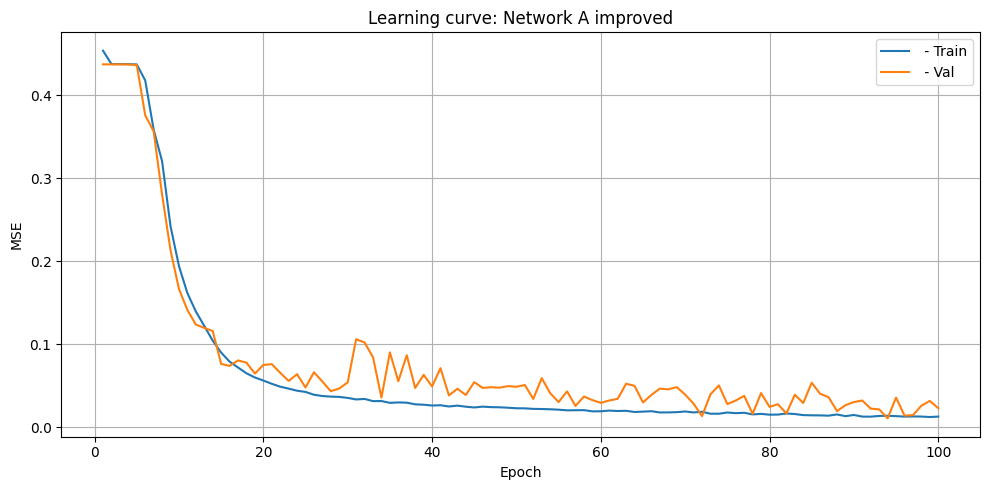

Saved → export/networkA_improv/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA_improv/trained_weights.csv


In [33]:
NetworkA['eta'] = 0.1 #lowering the learning rate
NetworkA['alpha'] = 0.5 #lowering the momentum
NetworkA['size'] = 12 #increasing the number of hidden layers

epochA_improv = Epoch(split, NetworkA)

train(epochA_improv, "Learning curve: Network A improved")
epochA_improv.exportAll("export/networkA_improv/")

The errors are now converging, although the validation error remains quite erratic relative to the training error. Training time is unchanged even with additional hidden layer nodes, suggesting a hardware or algorithmic bottleneck. Since convergence occurred early, training could reasonably be halted around the **60th epoch**; however, 100 epochs are maintained to target an error below **0.02**.

### Lowering the Learning Rate Further

The next experiment examines whether a further reduction in learning rate improves accuracy or convergence speed.

Epoch    5  Train: 0.43764  Val: 0.43749  Time: 0.667s
Epoch   10  Train: 0.43548  Val: 0.43166  Time: 0.675s
Epoch   15  Train: 0.34130  Val: 0.32748  Time: 0.700s
Epoch   20  Train: 0.19226  Val: 0.17902  Time: 0.602s
Epoch   25  Train: 0.11257  Val: 0.10518  Time: 0.626s
Epoch   30  Train: 0.06026  Val: 0.05662  Time: 0.607s
Epoch   35  Train: 0.04377  Val: 0.04094  Time: 0.602s
Epoch   40  Train: 0.03446  Val: 0.03546  Time: 0.575s
Epoch   45  Train: 0.02872  Val: 0.03455  Time: 0.605s
Epoch   50  Train: 0.02481  Val: 0.03297  Time: 0.625s
Epoch   55  Train: 0.02195  Val: 0.04065  Time: 0.604s
Epoch   60  Train: 0.02017  Val: 0.03974  Time: 0.608s
Epoch   65  Train: 0.01876  Val: 0.04032  Time: 0.641s
Epoch   70  Train: 0.01741  Val: 0.03954  Time: 0.595s
Epoch   75  Train: 0.01630  Val: 0.03804  Time: 0.591s
Epoch   80  Train: 0.01510  Val: 0.03744  Time: 0.581s
Epoch   85  Train: 0.01485  Val: 0.03245  Time: 0.616s
Epoch   90  Train: 0.01467  Val: 0.03214  Time: 0.619s
Epoch   95

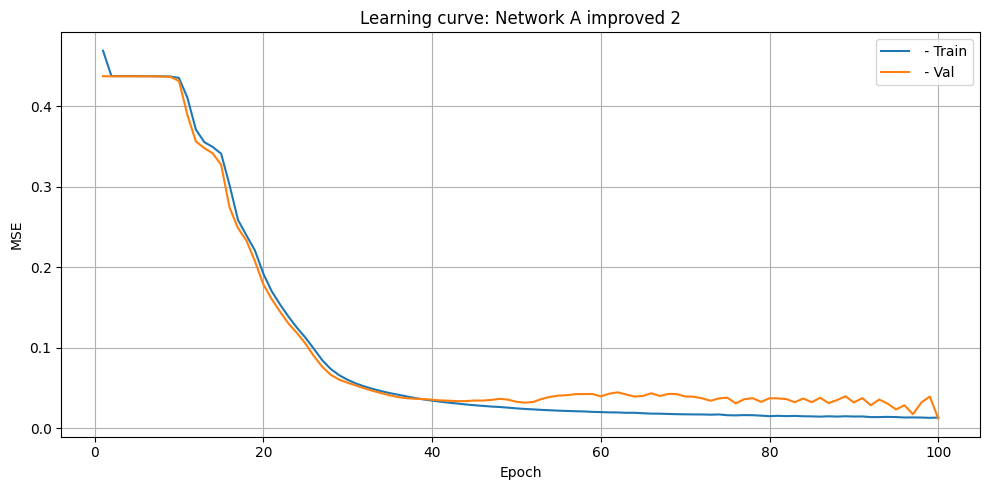

Saved → export/networkA_improv2/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA_improv2/trained_weights.csv


In [34]:
NetworkA['eta'] = 0.05 #decreasing learning rate to check if performance increases
NetworkA['alpha'] = 0.5 #keeping momentum
NetworkA['size'] = 12 #keeping same number 


epochA_improv2 = Epoch(split, NetworkA)

train(epochA_improv2, "Learning curve: Network A improved 2")
epochA_improv2.exportAll("export/networkA_improv2/")

The final error achieved is roughly equivalent to that of the previous configuration, suggesting the learning rate is near its optimal value for this architecture. However, the full **100 epochs** are required for the training error to fall below 0.02, as expected given that the learning rate was halved.

The **validation error** exhibits greater instability in this run. Training time is marginally faster at approximately 64 seconds, though the difference remains negligible.

### Increasing Momentum

In the following experiment, momentum is increased. Earlier convergence is anticipated, as higher momentum accelerates weight updates along consistent gradient directions.

Epoch    5  Train: 0.17904  Val: 0.17038  Time: 0.646s
Epoch   10  Train: 0.06154  Val: 0.08147  Time: 0.658s
Epoch   15  Train: 0.04423  Val: 0.06730  Time: 0.586s
Epoch   20  Train: 0.02943  Val: 0.03517  Time: 0.652s
Epoch   25  Train: 0.02651  Val: 0.02203  Time: 0.678s
Epoch   30  Train: 0.02251  Val: 0.02224  Time: 0.854s
Epoch   35  Train: 0.01948  Val: 0.01779  Time: 0.615s
Epoch   40  Train: 0.01785  Val: 0.01563  Time: 0.606s
Epoch   45  Train: 0.01674  Val: 0.01539  Time: 0.581s
Epoch   50  Train: 0.01516  Val: 0.01007  Time: 0.834s
Epoch   55  Train: 0.01716  Val: 0.00994  Time: 0.668s
Epoch   60  Train: 0.01561  Val: 0.00952  Time: 0.696s
Epoch   65  Train: 0.01663  Val: 0.01379  Time: 0.702s
Epoch   70  Train: 0.01369  Val: 0.01274  Time: 0.717s
Epoch   75  Train: 0.01269  Val: 0.01403  Time: 0.628s
Epoch   80  Train: 0.01165  Val: 0.01082  Time: 0.732s
Epoch   85  Train: 0.01353  Val: 0.00755  Time: 0.741s
Epoch   90  Train: 0.01038  Val: 0.01014  Time: 0.680s
Epoch   95

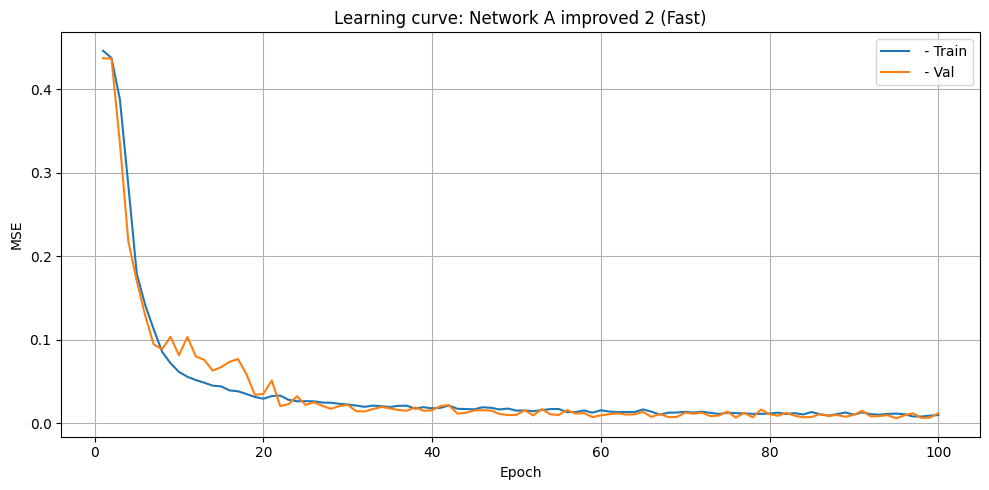

Saved → export/networkA_improv2_fast/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA_improv2_fast/trained_weights.csv


In [35]:
NetworkA['eta'] = 0.05 #keep
NetworkA['alpha'] = 0.9 #increasing momentum back
NetworkA['size'] = 12 #keeping size


epochA_improv2_fast = Epoch(split, NetworkA)

train(epochA_improv2_fast, "Learning curve: Network A improved 2 (Fast)")
epochA_improv2_fast.exportAll("export/networkA_improv2_fast/")

As anticipated, the higher momentum restores early-epoch convergence, with the training error falling below the target at approximately **epoch 35**. Total training time remains approximately 60 seconds for 100 epochs; however, the ability to halt training at epoch 35 represents a potential reduction in training time of more than half.

### Reducing Hidden Layer Size

The final experiment for Network A examines the effect of reducing the hidden layer size, retaining the current learning rate and momentum settings.

Epoch    5  Train: 0.28008  Val: 0.21758  Time: 0.638s
Epoch   10  Train: 0.12580  Val: 0.15311  Time: 0.630s
Epoch   15  Train: 0.10311  Val: 0.13735  Time: 0.612s
Epoch   20  Train: 0.08990  Val: 0.06264  Time: 0.647s
Epoch   25  Train: 0.06234  Val: 0.09279  Time: 0.609s
Epoch   30  Train: 0.05350  Val: 0.04125  Time: 0.582s
Epoch   35  Train: 0.04795  Val: 0.03113  Time: 0.654s
Epoch   40  Train: 0.03905  Val: 0.02946  Time: 0.619s
Epoch   45  Train: 0.03611  Val: 0.03286  Time: 0.609s
Epoch   50  Train: 0.03502  Val: 0.05472  Time: 0.584s
Epoch   55  Train: 0.03372  Val: 0.06690  Time: 0.693s
Epoch   60  Train: 0.03267  Val: 0.02538  Time: 0.603s
Epoch   65  Train: 0.02975  Val: 0.02976  Time: 0.670s
Epoch   70  Train: 0.02923  Val: 0.03696  Time: 0.586s
Epoch   75  Train: 0.02973  Val: 0.03563  Time: 0.625s
Epoch   80  Train: 0.02654  Val: 0.02226  Time: 0.649s
Epoch   85  Train: 0.02399  Val: 0.03320  Time: 0.636s
Epoch   90  Train: 0.02452  Val: 0.08063  Time: 0.572s
Epoch   95

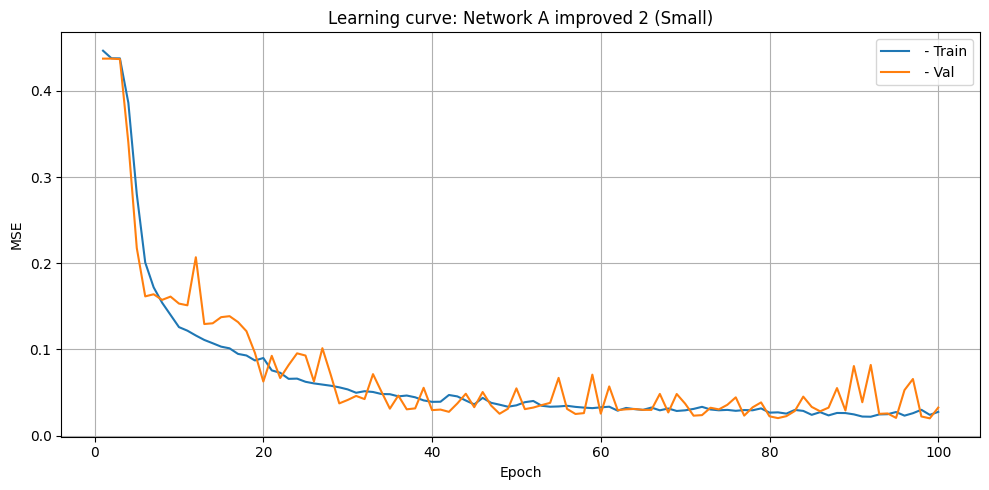

Saved → export/networkA_improv2_small/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA_improv2_small/trained_weights.csv


In [36]:
NetworkA['eta'] = 0.05 #keeping learning rate further
NetworkA['alpha'] = 0.9 #increasing momentum back
NetworkA['size'] = 5 #lowering size 


epochA_improv2_small = Epoch(split, NetworkA)

train(epochA_improv2_small, "Learning curve: Network A improved 2 (Small)")
epochA_improv2_small.exportAll("export/networkA_improv2_small/")

Despite the favorable learning rate and momentum settings established in the previous run, reducing the hidden layer size to 5 neurons causes convergence to slow considerably and the validation error to become more erratic. The network struggles to maintain a training error below 0.02 for both training and validation sets. This behavior is consistent with insufficient representational capacity, suggesting that a larger network or extended training duration is required when the model size is reduced.

## Training: Network B

Network B employs the **Leaky ReLU** activation function for both hidden layers and the **Logistic** function for the output layer. Training begins with the default hyperparameters to establish a baseline.

Epoch    5  Train: 0.44045  Val: 0.43843  Time: 0.667s
Epoch   10  Train: 0.44045  Val: 0.43843  Time: 0.766s
Epoch   15  Train: 0.44045  Val: 0.43843  Time: 0.625s
Epoch   20  Train: 0.44045  Val: 0.43843  Time: 0.680s
Epoch   25  Train: 0.44045  Val: 0.43843  Time: 0.641s
Epoch   30  Train: 0.44045  Val: 0.43843  Time: 0.700s
Epoch   35  Train: 0.40000  Val: 0.39674  Time: 0.690s
Epoch   40  Train: 0.39077  Val: 0.39094  Time: 0.775s


C:\Users\C5396183\AppData\Local\Temp\ipykernel_37780\621747645.py:3: RuntimeWarning: overflow encountered in exp
  phi = 1.0 / (1.0 + np.exp(-a * v))


Epoch   45  Train: 0.39070  Val: 0.39261  Time: 0.627s
Epoch   50  Train: 0.38707  Val: 0.38979  Time: 0.711s
Epoch   55  Train: 0.38739  Val: 0.39085  Time: 0.723s
Epoch   60  Train: 0.38887  Val: 0.39918  Time: 0.665s
Epoch   65  Train: 0.38685  Val: 0.38977  Time: 0.661s
Epoch   70  Train: 0.87410  Val: 0.88875  Time: 0.749s
Epoch   75  Train: 0.87410  Val: 0.88875  Time: 0.699s
Epoch   80  Train: 0.87410  Val: 0.88875  Time: 0.697s
Epoch   85  Train: 0.87410  Val: 0.88875  Time: 0.644s
Epoch   90  Train: 0.87410  Val: 0.88875  Time: 0.756s
Epoch   95  Train: 0.87410  Val: 0.88875  Time: 0.683s
Epoch  100  Train: 0.87410  Val: 0.88875  Time: 0.707s
Confusion Matrix (rows=Actual, cols=Predicted):
      P 1  P 2  P 3  P 4  P 5  P 6  P 7  P 8
A 1 |   89     0     0     0     0     0     0     0
A 2 |   82     0     0     0     0     0     0     0
A 3 |  106     0     0     0     0     0     0     0
A 4 |  119     0     0     0     0     0     0     0
A 5 |   94     0     0     0     0 

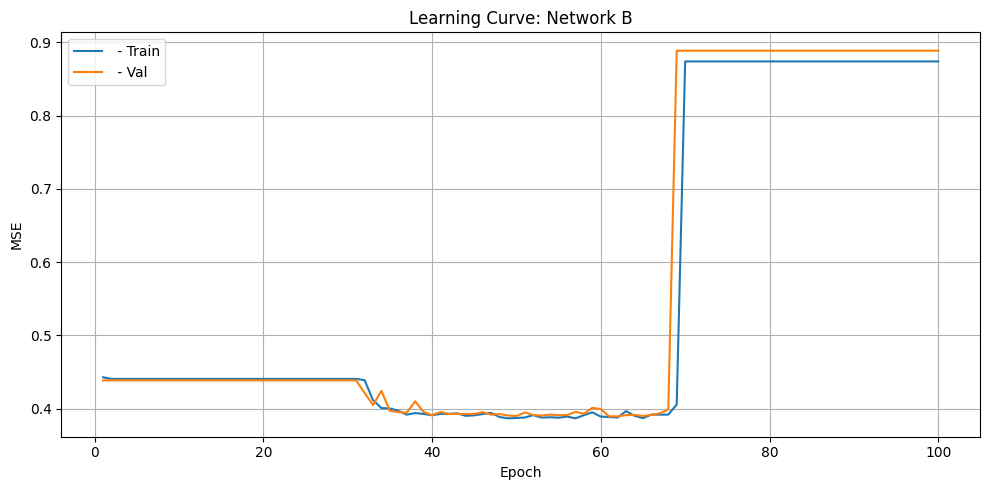

Saved → export/networkB/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB/trained_weights.csv


In [37]:
train(epochB, "Learning Curve: Network B") #network B
epochB.exportAll("export/networkB/")

### Improvements: Network B

The default learning rate of 0.85 is again too high; the training error does not decrease across any epoch, consistent with the behavior observed in Network A. The same tuning strategy is applied: `eta=0.1`, `alpha=0.5`, `size=12`.

Epoch    5  Train: 0.43769  Val: 0.43751  Time: 0.730s
Epoch   10  Train: 0.37154  Val: 0.35710  Time: 0.709s
Epoch   15  Train: 0.14689  Val: 0.15515  Time: 0.725s
Epoch   20  Train: 0.07589  Val: 0.10088  Time: 0.851s
Epoch   25  Train: 0.05562  Val: 0.05034  Time: 0.700s
Epoch   30  Train: 0.04239  Val: 0.04535  Time: 0.690s
Epoch   35  Train: 0.03480  Val: 0.04805  Time: 0.682s
Epoch   40  Train: 0.03133  Val: 0.03365  Time: 0.682s
Epoch   45  Train: 0.02709  Val: 0.03857  Time: 0.689s
Epoch   50  Train: 0.02440  Val: 0.03386  Time: 0.755s
Epoch   55  Train: 0.02194  Val: 0.05498  Time: 0.727s
Epoch   60  Train: 0.01953  Val: 0.02350  Time: 0.634s
Epoch   65  Train: 0.01837  Val: 0.03718  Time: 0.700s
Epoch   70  Train: 0.01710  Val: 0.04127  Time: 0.784s
Epoch   75  Train: 0.01589  Val: 0.03873  Time: 0.742s
Epoch   80  Train: 0.01498  Val: 0.02283  Time: 0.713s
Epoch   85  Train: 0.01550  Val: 0.02446  Time: 0.683s
Epoch   90  Train: 0.01488  Val: 0.03898  Time: 0.750s
Epoch   95

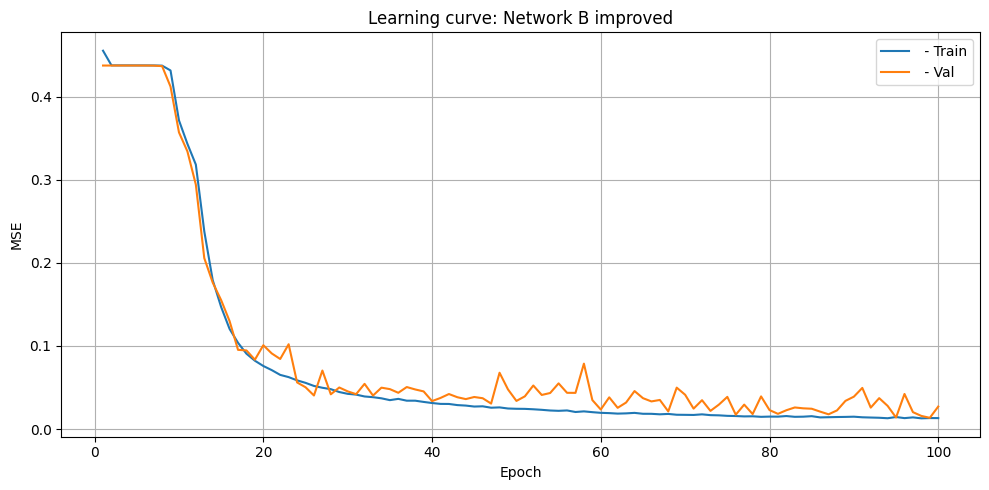

Saved → export/networkB_improv/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB_improv/trained_weights.csv


In [38]:
NetworkB['eta'] = 0.1 #decreasing the learning rate like Network A improv
NetworkB['alpha'] = 0.5 #decreasing the momentum
NetworkB['size'] = 12 #increasing hidden layer nodes

epochB_improv = Epoch(split, NetworkB)

train(epochB_improv, "Learning curve: Network B improved")
epochB_improv.exportAll("export/networkB_improv/")

Although convergence is achieved, the validation error diverges from the training error toward the end of the run, largely due to a high number of false positives for Class 6. The source of this misclassification is not immediately apparent; the learning rate is reduced further to determine whether this improves classification performance. No change in training time is observed, remaining at approximately 70 seconds.

### Lowering the Learning Rate Further

Epoch    5  Train: 0.43762  Val: 0.43758  Time: 0.888s
Epoch   10  Train: 0.43758  Val: 0.43753  Time: 0.850s
Epoch   15  Train: 0.43547  Val: 0.43299  Time: 0.720s
Epoch   20  Train: 0.34329  Val: 0.33342  Time: 0.835s
Epoch   25  Train: 0.19063  Val: 0.18020  Time: 0.691s
Epoch   30  Train: 0.11803  Val: 0.11321  Time: 0.758s
Epoch   35  Train: 0.06758  Val: 0.06735  Time: 0.642s
Epoch   40  Train: 0.04877  Val: 0.04646  Time: 0.746s
Epoch   45  Train: 0.04063  Val: 0.04588  Time: 0.735s
Epoch   50  Train: 0.03540  Val: 0.03454  Time: 0.693s
Epoch   55  Train: 0.03065  Val: 0.03318  Time: 0.727s
Epoch   60  Train: 0.02663  Val: 0.02728  Time: 0.845s
Epoch   65  Train: 0.02294  Val: 0.03201  Time: 0.715s
Epoch   70  Train: 0.02107  Val: 0.02542  Time: 0.817s
Epoch   75  Train: 0.01839  Val: 0.03330  Time: 0.687s
Epoch   80  Train: 0.01690  Val: 0.02560  Time: 0.687s
Epoch   85  Train: 0.01578  Val: 0.02888  Time: 0.742s
Epoch   90  Train: 0.01476  Val: 0.03012  Time: 0.682s
Epoch   95

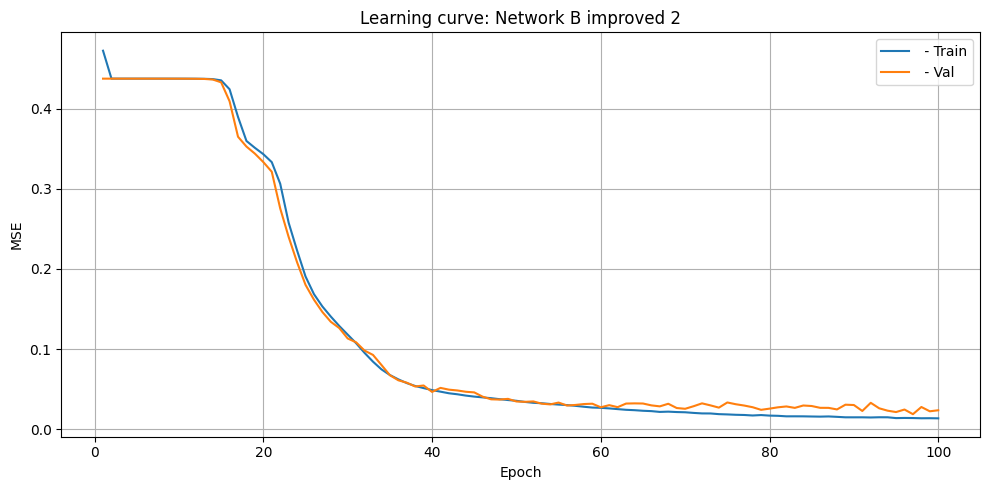

Saved → export/networkB_improv2/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB_improv2/trained_weights.csv


In [39]:
NetworkB['eta'] = 0.05 #decreasing the learning rate like Network A improv2
NetworkB['alpha'] = 0.5 #keaping the momentum
NetworkB['size'] = 12 #keep

epochB_improv2 = Epoch(split, NetworkB)

train(epochB_improv2, "Learning curve: Network B improved 2")
epochB_improv2.exportAll("export/networkB_improv2/")

Reducing the learning rate further improves the macro F1 score and stabilizes the validation error by the end of the 100-epoch run. However, the network still struggles to maintain a low error in intermediate epochs, with Classes 6 and 8 contributing the most to classification errors. Weight improvement is first observed around epoch 20, which is consistent with the slower learning dynamics introduced by the reduced learning rate.

Examination of the SMOTE-balanced distribution does not reveal evidence of residual class imbalance as the cause of Class 6 misclassifications, as that class was well-represented in the original dataset and received proportional synthetic augmentation.

### Increasing Momentum

Momentum is increased to determine whether the reduction in false positives observed in earlier Network A experiments can be reproduced for Network B.

Epoch    5  Train: 0.43608  Val: 0.42073  Time: 0.826s
Epoch   10  Train: 0.12597  Val: 0.08805  Time: 0.746s
Epoch   15  Train: 0.08269  Val: 0.14469  Time: 0.741s
Epoch   20  Train: 0.05403  Val: 0.06057  Time: 0.701s
Epoch   25  Train: 0.04250  Val: 0.07017  Time: 0.705s
Epoch   30  Train: 0.03424  Val: 0.07164  Time: 0.737s
Epoch   35  Train: 0.03235  Val: 0.02286  Time: 0.698s
Epoch   40  Train: 0.03268  Val: 0.01750  Time: 0.791s
Epoch   45  Train: 0.02798  Val: 0.04472  Time: 0.743s
Epoch   50  Train: 0.02947  Val: 0.01741  Time: 0.748s
Epoch   55  Train: 0.02476  Val: 0.01632  Time: 0.709s
Epoch   60  Train: 0.02574  Val: 0.01356  Time: 0.783s
Epoch   65  Train: 0.02073  Val: 0.01442  Time: 0.755s
Epoch   70  Train: 0.02085  Val: 0.01880  Time: 0.860s
Epoch   75  Train: 0.02075  Val: 0.01370  Time: 0.748s
Epoch   80  Train: 0.02127  Val: 0.01185  Time: 0.681s
Epoch   85  Train: 0.02069  Val: 0.01206  Time: 0.698s
Epoch   90  Train: 0.02428  Val: 0.01228  Time: 0.666s
Epoch   95

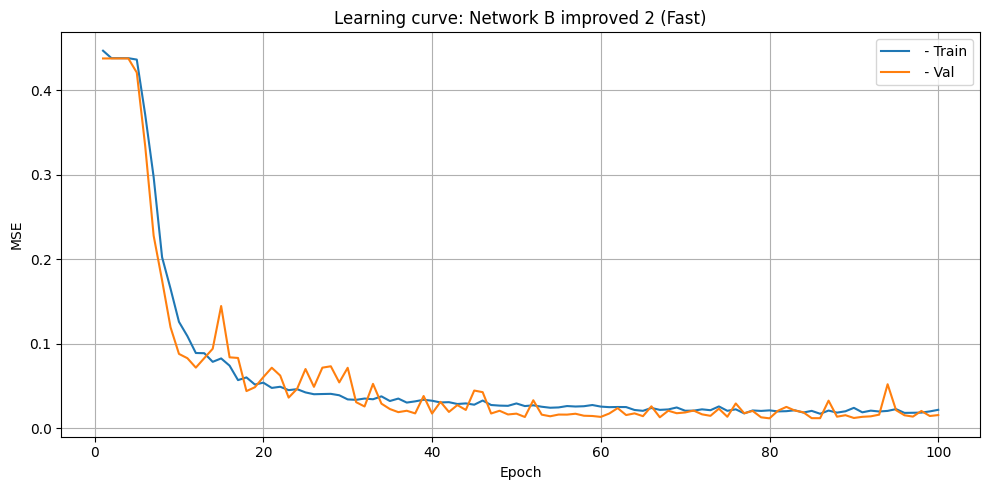

Saved → export/networkB_improv2_fast/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB_improv2_fast/trained_weights.csv


In [40]:
NetworkB['eta'] = 0.05 #decreasing the learning rate like Network A improv2
NetworkB['alpha'] = 0.9 #keaping the momentum
NetworkB['size'] = 12 #increasing hidden layer nodes

epochB_improv2_fast = Epoch(split, NetworkB)

train(epochB_improv2_fast, "Learning curve: Network B improved 2 (Fast)")
epochB_improv2_fast.exportAll("export/networkB_improv2_fast/")

This configuration yields a notable improvement, reducing Class 6 false positives from 19 to 3. The training error converges erratically with an elevated floor, narrowly missing the 0.02 target; however, the error approaches this threshold at approximately **epoch 65**. The validation error is noticeably more stable than the training error, suggesting reasonable generalization.

### Reducing Hidden Layer Size

The following experiment investigates whether the classification improvements are retained when the hidden layer size is reduced.

Epoch    5  Train: 0.43773  Val: 0.43747  Time: 0.694s
Epoch   10  Train: 0.30857  Val: 0.25792  Time: 0.593s
Epoch   15  Train: 0.17128  Val: 0.16463  Time: 0.640s
Epoch   20  Train: 0.14412  Val: 0.17945  Time: 0.691s
Epoch   25  Train: 0.12478  Val: 0.15920  Time: 0.753s
Epoch   30  Train: 0.11926  Val: 0.13920  Time: 0.690s
Epoch   35  Train: 0.11649  Val: 0.13614  Time: 0.718s
Epoch   40  Train: 0.11082  Val: 0.17333  Time: 0.642s
Epoch   45  Train: 0.10819  Val: 0.09946  Time: 0.660s
Epoch   50  Train: 0.10622  Val: 0.10226  Time: 0.869s
Epoch   55  Train: 0.10555  Val: 0.09650  Time: 0.699s
Epoch   60  Train: 0.10437  Val: 0.10077  Time: 0.777s
Epoch   65  Train: 0.09714  Val: 0.09967  Time: 0.735s
Epoch   70  Train: 0.09527  Val: 0.11090  Time: 0.663s
Epoch   75  Train: 0.09745  Val: 0.12677  Time: 0.767s
Epoch   80  Train: 0.09135  Val: 0.08910  Time: 0.692s
Epoch   85  Train: 0.09718  Val: 0.12279  Time: 0.690s
Epoch   90  Train: 0.09177  Val: 0.08500  Time: 0.646s
Epoch   95

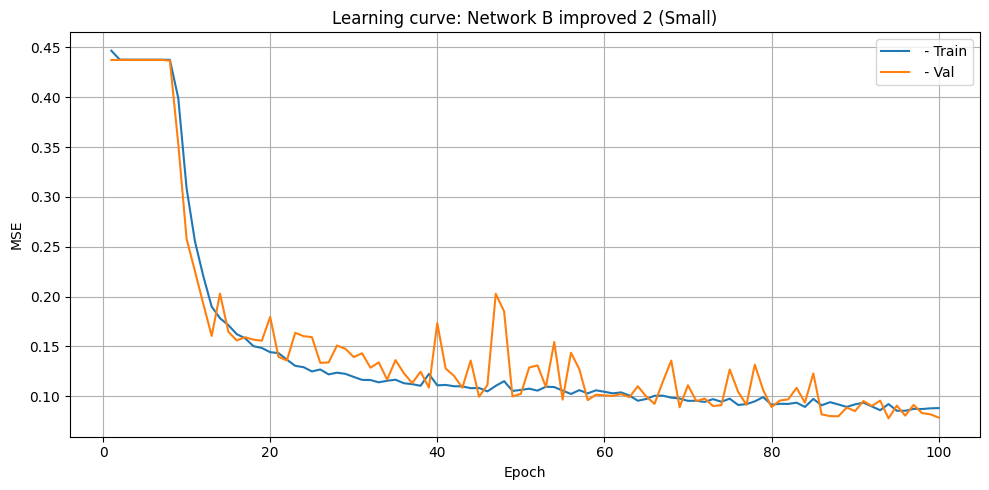

Saved → export/networkB_improv2_small/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB_improv2_small/trained_weights.csv


In [41]:
NetworkB['eta'] = 0.05 #keeping the learning rate like Network A improv2 fast
NetworkB['alpha'] = 0.9 #increasing the momentum
NetworkB['size'] = 5 #decreasing hidden nodes

epochB_improv2_small = Epoch(split, NetworkB)

train(epochB_improv2_small, "Learning curve: Network B improved 2 (Small)")
epochB_improv2_small.exportAll("export/networkB_improv2_small/")

Reducing the hidden layer size to 5 nodes yields no improvement over the larger-network configuration. The macro F1 and Matthews Correlation Coefficient scores are noticeably lower compared to the larger variant, confirming that representational capacity is a limiting factor for Network B as well.

# Training Results

After training all network configurations, the results are compiled and ranked by F1 score and approximate epoch of convergence. Time was recorded when convergence was met.

In [42]:
!python checkscores.py

Loaded 1 rows from networkA
Loaded 1 rows from networkA_improv
Loaded 1 rows from networkA_improv2
Loaded 1 rows from networkA_improv2_fast
Loaded 1 rows from networkA_improv2_small
Loaded 1 rows from networkB
Loaded 1 rows from networkB_improv
Loaded 1 rows from networkB_improv2
Loaded 1 rows from networkB_improv2_fast
Loaded 1 rows from networkB_improv2_small

Combined 10 total rows written to combined_scores.csv
Full scores written to final\full_scores.csv
Best score written to final\scores.csv (Network: networkA_improv2, F1: 0.985960)


In [51]:
allepochA = [epochA, epochA_improv, epochA_improv2, epochA_improv2_fast, epochA_improv2_small]
epochA.label = "Network A TanH (eta=0.85, alpha=0.9, 8L)"
epochA_improv.label = "Network A TanH (eta=0.1, alpha=0.5, 12L)"
epochA_improv2.label = "Network A TanH (eta=0.05, 12L)"
epochA_improv2_fast.label = "Network A TanH (alpha=0.9, 12L)"
epochA_improv2_small.label = "Network A TanH (5L)"

allepochB = [epochB, epochB_improv, epochB_improv2, epochB_improv2_fast, epochB_improv2_small]
epochB.label = "Network A TanH (eta=0.85, alpha=0.9, 8L)"
epochB_improv.label = "Network A TanH (eta=0.1, alpha=0.5, 12L)"
epochB_improv2.label = "Network A TanH (eta=0.05, 12L)"
epochB_improv2_fast.label = "Network B (alpha=0.9, 12L)"
epochB_improv2_small.label = "Network B ReLU (5L)"

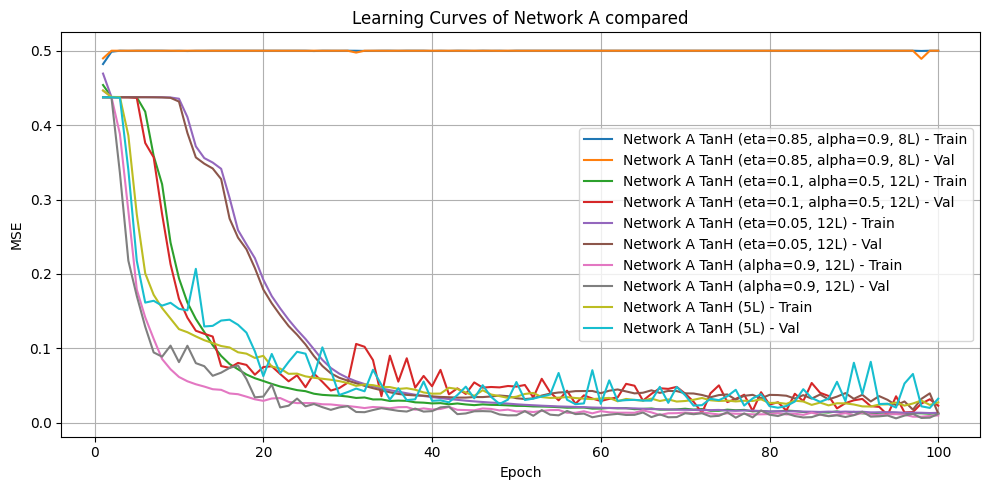

In [52]:
learningcurve(allepochA, "Learning Curves of Network A compared")

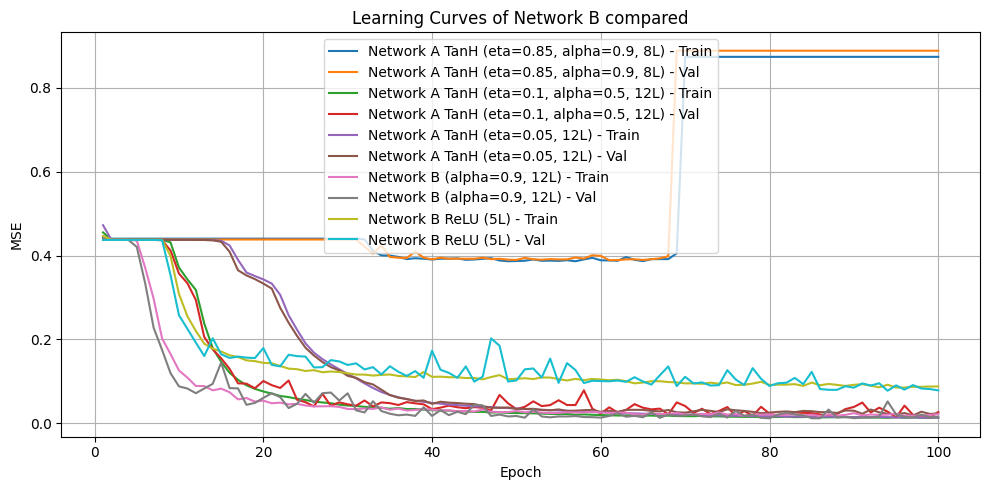

In [53]:
learningcurve(allepochB, "Learning Curves of Network B compared")

## Results

# **Ranked by F1 Macro**

| Rank   | Network                      | Epoch (MSE<0.02) | f1\_macro        | Notes                               |
| ------ | ---------------------------- | ----- | ---------------- | ----------------------------------- |
| **1**  | **networkA\_improv2**        | 97   | **0.9859595801** | Highest overall, converges at the end|
| **2**  | **networkA\_improv2\_fast**  | 35   | **0.9852927986** | Very close to #1, fastest to converge|
| **3**  | **networkB\_improv2\_fast**  | 65   | **0.9818658635** | Best of networkB variants, also fast |
| **4**  | **networkB\_improv2**        | 97   | **0.9778340093** | Strong performance, converges at the end|
| **5**  | **networkA\_improv**         | 72   | **0.9729664191** | High-performing                     |
| **6**  | **networkB\_improv**         | 76   | **0.9655926201** | Slightly lower than A\_improv       |
| **7**  | **networkA\_improv2\_small** | 100+  | **0.9615743104** | Compact version but still strong    |
| **8**  | **networkB\_improv2\_small** | 100+  | **0.9143215932** | Noticeable drop vs. larger variants |
| **9**  | **networkA**                 | DNF   | **0.2261640798** | Very low class-level metrics        |
| **10** | **networkB**                 | DNF   | **0.0250281215** | Lowest f1\_macro                    |



## Full Scores Results

| Rank   | Network                  | Epoch (MSE<0.02) | Accuracy | Precision | MCC  | F1 Score    | Recall | Time     |
| ------ | ------------------------ | ------------------ | -------- | --------- | ------- | ----------- | -------- | -------- |
| **1**  | networkA\_improv2        | 97                | 0.98625  | 0.97727   | 0.98428 | **0.98596** | 0.98634  | 62.36157 |
| **2**  | networkA\_improv2\_fast  | 35                | 0.98500  | 0.98889   | 0.98287 | **0.98529** | 0.98565  | 68.34060 |
| **3**  | networkB\_improv2\_fast  | 65                | 0.98125  | 0.98324   | 0.97866 | **0.98187** | 0.98220  | 74.50795 |
| **4**  | networkB\_improv2        | 97                | 0.97750  | 0.98324   | 0.97448 | **0.97783** | 0.97773  | 76.56250 |
| **5**  | networkA\_improv         | 72                | 0.97250  | 0.98343   | 0.96890 | **0.97297** | 0.97396  | 65.33471 |
| **6**  | networkB\_improv         | 76                | 0.96500  | 0.98324   | 0.96032 | **0.96559** | 0.96604  | 73.22172 |
| **7**  | networkA\_improv2\_small | 100+                | 0.96125  | 0.96629   | 0.95611 | **0.96157** | 0.96249  | 63.41435 |
| **8**  | networkB\_improv2\_small | 100+                | 0.91375  | 0.90058   | 0.90183 | **0.91432** | 0.91353  | 71.15322 |
| **9**  | networkA                 | DNF                | 0.12750  | 0.00000   | 1.00000 | **0.22616** | 0.12500  | 63.60271 |
| **10** | networkB                 | DNF                | 0.11125  | 0.20022   | 0.00000 | **0.02503** | 0.12500  | 71.80073 |

## Training Time Results

Adding in a value so that we can compare normalized training time to get an equivalent 0.02 MSE:

$$ \text{Time‑Adjusted} = \text{Time} × (\text{Epoch}_{\text{converged}} / 100) $$

Special rules:

*   If **Epoch\_converged > 100**, multiplier = **1.00**
*   If **DNF**, then Time‑Adjusted = **N/A**

| Rank   | Network                  | Epoch | Time (s) | Time‑Adjusted | Your Notes |
| ------ | ------------------------ | ----- | -------- | ------------- | ---------- |
| **1**  | networkA\_improv2\_fast  | 35    | 68.34060 | **23.91921**  | $\alpha=0.9, \eta=0.05, size=12$           |
| **2**  | networkA\_improv         | 72    | 65.33471 | **47.04099**  | $\alpha=0.5, \eta=0.1, size=12$           |
| **3**  | networkB\_improv2\_fast  | 65    | 74.50795 | **48.43017**  | $\alpha=0.9, \eta=0.05, size=12$           |
| **4**  | networkB\_improv         | 76    | 73.22172 | **55.64851**  | $\alpha=0.5, \eta=0.1, size=12$           |
| **5**  | networkA\_improv2        | 97    | 62.36157 | **60.49072**  | $\alpha=0.5, \eta=0.05, size=12$           |
| **6**  | networkA\_improv2\_small | 100+  | 63.41435 | **63.41435**  | $\alpha=0.9, \eta=0.05, size=5$           |
| **7**  | networkB\_improv2        | 97    | 76.56250 | **74.26563**  | $\alpha=0.5, \eta=0.05, size=12$           |
| **8**  | networkB\_improv2\_small | 100+  | 71.15322 | **71.15322**  | $\alpha=0.9, \eta=0.05, size=5$           |
| **9**  | networkA                 | DNF   | 63.60271 | **N/A**       | $\alpha=0.9, \eta=0.85, size=8$           |
| **10** | networkB                 | DNF   | 71.80073 | **N/A**       | $\alpha=0.9, \eta=0.85, size=8$           |

A tradeoff exists between peak F1 performance and time-adjusted training cost. Configurations that fail to converge are disqualified regardless of raw metric values. Among converging configurations, **networkA\_improv2\_fast** offers the most favorable balance of F1 score and adjusted training time.

**Network A (improved2, Fast)** with Tanh achieves the best overall result for Network A, recording a macro-averaged **F1 score of 0.98529** and converging below 0.02 MSE at epoch 35. With early stopping applied, the adjusted training time is approximately **24 seconds**. Its trained weights are exported to `modelA/trained_weights.csv` as the primary model for the unseen test set. A close second, **Network A (improved2)**, achieves a marginally higher **F1 score of 0.98596** but requires 97 epochs to converge due to its lower momentum.

**Network B (improved2, Fast)** with Leaky ReLU is the best configuration for Network B, recording a **macro-averaged F1 score of 0.98187**. Convergence occurs at approximately epoch 65, yielding an adjusted training time of approximately 48 seconds. Its weights are exported to `modelB/trained_weights.csv` as the backup model.

The two default-parameter configurations failed to converge entirely, yielding F1 scores of 0.2261 and 0.0250 with MCC values near 0.125, confirming that no meaningful learning occurred.

## Loading the Model

Trained weights are loaded from CSV files using the `loadWeights` function. The function reads the weight matrix, parses the layer dimensions, and returns properly shaped arrays ready for reconstruction.

In [54]:
epochA_improv2_fast.exportWeights("modelA/")
epochB_improv2_fast.exportWeights("modelB/")

Saved → modelA/trained_weights.csv
Saved → modelB/trained_weights.csv


In [55]:
def loadWeights(path):
    blocks = {'Wi': [], 'Wj': [], 'Wk': []}
    current = None
    with open(path, newline='') as f:
        reader = csv.reader(f)
        for row in reader:
            if not row or row[0].strip() == '':
                continue
            tag = row[0].strip()
            if tag in blocks:
                current = tag
                continue
            if current is not None:
                blocks[current].append([float(v) for v in row])
    return (np.array(blocks['Wi']),
            np.array(blocks['Wj']),
            np.array(blocks['Wk']))

## Running and Exporting the Predictions

The `runPredictions` function takes the loaded weights and test set, reconstructs the network layers, and performs a forward pass for each test sample. Predictions are determined by taking the `argmax` of the output layer activations.

The best two models are used:
- **Network B improved** (Leaky ReLU) → `predictions/networkB_improv_predictions.csv`
- **Network A improved fast** (Tanh) → `predictions/networkA_improv_fast_predictions.csv`

In [56]:
def runPredictions(model, testset, cfg):
    if isinstance(model, tuple):
        Wi, Wj, Wk = model
        layerI = HiddenLayer(cfg['methods'][0], Wi, cfg, size=Wi.shape[0])
        layerJ = HiddenLayer(cfg['methods'][1], Wj, cfg, size=Wj.shape[0])
        layerK = OutputLayer(cfg['methods'][2], Wk, cfg)
    else:
        layerI = model.hiddenlayer_i
        layerJ = model.hiddenlayer_j
        layerK = model.outputlayer_k

    predictions = []
    for x in testset:
        xb   = np.concatenate(([1.0], np.asarray(x, dtype=float)))
        phiI = layerI.forward(xb)
        phiJ = layerJ.forward(phiI)
        layerK.forward(phiJ)
        label = int(np.argmax(layerK.o)) + 1
        predictions.append(label)
    return predictions

def exportPredictions(predictions, filename="predictions_for_test_networkA.csv"):
    outputdir = "predictions"
    os.makedirs(outputdir, exist_ok=True)
    filepath = os.path.join(outputdir, filename)
    with open(filepath, 'w', newline='') as f:
        writer = csv.writer(f)
        for p in predictions:
            writer.writerow([p])
    print(f"Saved {len(predictions)} predictions → {filepath}")

In [57]:
#for sanity's sake, this is the parsed  TESTSET from test_set.csv
print(TESTSET)
print(f"TESTSET : {TESTSET.shape}")

[[2.2071e-02 1.5208e-02 0.0000e+00 ... 4.9787e-03 9.8536e-01 6.6436e-02]
 [2.7050e-02 1.4022e-02 8.7247e-04 ... 2.5246e-02 9.0283e-01 2.7611e-01]
 [4.0489e-02 2.9229e-02 1.7990e-03 ... 1.0859e-02 9.2096e-01 2.6831e-01]
 ...
 [1.6607e-02 2.0379e-02 5.2598e-04 ... 4.4773e-03 9.8416e-01 8.9833e-02]
 [5.6162e-03 5.2749e-03 0.0000e+00 ... 7.8382e-03 9.7868e-01 1.4204e-01]
 [1.1618e-02 1.1367e-02 1.9311e-04 ... 9.4570e-03 8.8809e-01 2.1509e-01]]
TESTSET : (701, 354)


In [58]:
WEIGHTSA = os.path.join("modelA", "trained_weights.csv") #tanh
WEIGHTSB = os.path.join("modelB", "trained_weights.csv") #leakyrelu

MODELA = loadWeights(WEIGHTSA)
MODELB = loadWeights(WEIGHTSB)

predictions_tanh = runPredictions(MODELA, TESTSET, NetworkA)
predictions_relu = runPredictions(MODELB, TESTSET, NetworkB)

#exporting predictions
exportPredictions(predictions_tanh, filename="predictions_for_test_tanh.csv")
exportPredictions(predictions_relu, filename="predictions_for_test_leakyrelu.csv")


Saved 701 predictions → predictions\predictions_for_test_tanh.csv
Saved 701 predictions → predictions\predictions_for_test_leakyrelu.csv


# Conclusion and Recommendations

This study implemented and evaluated a Multilayer Perceptron trained via the Backpropagation Algorithm on an 8-class dataset. Ten network configurations were explored across two activation function families (Tanh and Leaky ReLU), with systematic variation of the learning rate ($\eta$), momentum coefficient ($\alpha$), and hidden layer size.

## Conclusions

The following conclusions are drawn from the experimental results:

1. **Default hyperparameters are insufficient.** Both Network A and Network B failed to learn meaningful representations when trained with $\eta = 0.85$ and $\alpha = 0.9$. The excessively large weight updates caused the networks to collapse to single-class predictions, yielding F1 scores of 0.2261 and 0.0250 respectively.

2. **Reducing the learning rate is the most critical intervention.** Lowering $\eta$ from 0.85 to 0.1 was sufficient to achieve convergence in both network families. A further reduction to 0.05 produced comparable or slightly higher F1 scores at the cost of slower convergence.

3. **Momentum accelerates convergence without degrading accuracy.** Restoring $\alpha$ to 0.9 after a stable learning rate was established reduced the epoch of convergence from approximately 97 to 35 for Network A and from 97 to 65 for Network B, while maintaining near-identical final F1 scores.

4. **Hidden layer size of 12 outperforms size 5.** Compact networks (size 5) consistently exhibited slower convergence, higher validation error variance, and lower F1 scores across both activation functions, confirming that the 2052-dimensional input space requires sufficient representational capacity in the hidden layers.

5. **Tanh marginally outperforms Leaky ReLU on this dataset.** The top-ranked Tanh configurations (networkA\_improv2 and networkA\_improv2\_fast) achieved F1 scores of 0.98596 and 0.98529 respectively, compared to 0.98187 for the best Leaky ReLU variant. Both activation functions are viable; however, Tanh converges more reliably on this task.

## Recommendations

Based on the results, the following recommendations are made:

- **For deployment**, `networkA_improv2_fast` (Tanh, $\eta = 0.05$, $\alpha = 0.9$, hidden size 12) is recommended as the primary model. It achieves a macro-averaged F1 score of **0.98529** and an adjusted training time of approximately **24 seconds**, offering the best balance of accuracy and efficiency. Its trained weights are stored in `modelA/trained_weights.csv`.

- **As a backup**, `networkB_improv2_fast` (Leaky ReLU, $\eta = 0.05$, $\alpha = 0.9$, hidden size 12) is recommended. It achieves a macro-averaged F1 score of **0.98187** with an adjusted training time of approximately **48 seconds**, and its weights are stored in `modelB/trained_weights.csv`.

- **For future work**, early stopping based on validation error should be formally implemented to avoid unnecessary computation. Additionally, SMOTE should be applied strictly within the training fold after the train-validation split to eliminate the risk of data leakage into the validation set.